<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 3 - Phase 3 - eyamrog

This phase aims to compile the QJPP corpus (Human-Authored Reference Corpus).

- **Definition of text**:
    - Academic research articles;
    - Organised in sections: Abstract, Introduction, Literature Review, Methodology, Results, Discussion, Conclusion, Acknowledgements;
    - Paragraphs longer than or equal to 10 words.

## Required Python packages

- pandas
- nltk

## Importing the required libraries

In [1]:
import pandas as pd
import os
import sys
import nltk
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import random

## Defining input variables

In [2]:
input_directory = 'cl_st3_ph3_eyamrog'
output_directory = 'cl_st3_ph3_eyamrog'

## Create output directory

In [3]:
# Check if the output directory already exists. If it does, do nothing. If it doesn't exist, create it.
if os.path.exists(output_directory):
    print('Output directory already exists.')
else:
    try:
        os.makedirs(output_directory)
        print('Output directory successfully created.')
    except OSError as e:
        print('Failed to create the directory:', e)
        sys.exit(1)

Output directory already exists.


### Import the data into a DataFrame

In [4]:
df_qjpp = pd.read_json(f"{input_directory}/df_qjpp.jsonl", lines=True)

In [5]:
df_qjpp['Published'] = pd.to_datetime(df_qjpp['Published'], unit='ms')

## Data Wrangling

### Paragraphs shorter than 10 words

In [6]:
# Slice the DataFrame where 'Text Paragraph' contains fewer than 10 words
df_less_than_10_words = df_qjpp[df_qjpp['Text Paragraph'].apply(lambda x: len(str(x).split())) < 10]

In [7]:
# Write the contents of the column 'Text Paragraph' to a text file
df_less_than_10_words['Text Paragraph'].to_csv(f"{output_directory}/df_less_than_10_words.txt", index=False, header=False)

In [8]:
# Get the indexes of rows where 'Text Paragraph' contains less than 10 words
index_list_less_than_10_words = df_qjpp[df_qjpp['Text Paragraph'].apply(lambda x: len(str(x).split())) < 10].index.tolist()

In [9]:
len(index_list_less_than_10_words)

52

### Dropping the filtered rows

In [10]:
df_qjpp.drop(index_list_less_than_10_words, inplace=True)

In [11]:
df_qjpp

,Journal,Title,Authors,Published,Vol/Issue,URL,DOI,PDF URL,Discipline,ID,Text ID,Section,Paragraph,Text Paragraph
0,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,Abstract,Paragraph 1,The severe acute respiratory syndrome coronavi...
1,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,"Introduction, Literature Review",Paragraph 1,"Since its emergence in Wuhan, China, at the en..."
2,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,"Introduction, Literature Review",Paragraph 2,"By January 2022, approximately 49% of the glob..."
3,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,"Introduction, Literature Review",Paragraph 3,Low-income and lower-middle-income countries h...
4,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,"Introduction, Literature Review",Paragraph 4,In high-income countries that have achieved hi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14386,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 32,"However, compared with the writers of New Zeal..."
14387,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 33,Prommas’s (2020 ) finding of the lower use of ...
14388,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 34,The findings of this mixed-methods study were ...
14389,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,Conclusion,Paragraph 1,"In this paper, we attempted to highlight the s..."


### Minimum and maximum paragraph lengths in the column `Text Paragraph`

In [12]:
# Calculate the length of each paragraph
paragraph_lengths = df_qjpp['Text Paragraph'].apply(lambda x: len(str(x).split()))

# Get the minimum and maximum lengths
min_length = paragraph_lengths.min()
max_length = paragraph_lengths.max()

# Display the results
min_length, max_length

(10, 3347)

### Identifying characters that could be problematic for processing

#### In column `Text Paragraph`

In [13]:
# Combine all paragraphs into a single string
combined_text = ''.join(df_qjpp['Text Paragraph'].dropna())

# Get the set of unique characters
unique_characters = set(combined_text)

# Display the set of characters
print(unique_characters)

{'适', '𝜔', 'q', '放', 'ξ', 'Ε', '̂', 'ℎ', '«', '*', 't', 'r', 'æ', '°', 'χ', '»', '式', 'Α', 'l', '6', '́', 'Ω', '←', 'ʹ', '∀', '…', '±', '”', 'E', '南', 'Μ', '铁', '𝜇', '÷', 'ˆ', 'ł', '妈', 'x', '好', '境', 'ò', 'ϴ', 'B', '´', 'Č', '学', '佐', ')', 'h', '—', '7', 'f', '最', '你', '己', '𝑛', '话', 'ﬁ', '在', '电', '之', 'ɡ', '一', '言', '–', ':', 'D', '″', 'ṭ', '怎', '古', 'ʊ', 'ă', 'ì', '饭', 'έ', 'ɾ', 'ā', '。', '法', '国', '没', '发', '遇', 'ō', '𝜌', '中', '顔', '我', '诗', '𝛥', '&', 'ô', 'β', '?', '∧', '·', '\\', '⋅', 'y', 'ß', '吃', '释', '𝑥', '∫', 'T', '<', 'j', 'な', '选', '每', 'ί', 'ḍ', '𝑄', '½', 'Q', 'ḥ', '上', '得', '三', '从', '高', 'ɜ', 'Ψ', '𝑘', '#', 'ñ', '，', '招', '度', '变', 'С', 'ɛ', 'τ', '录', '∗', 'μ', '决', '和', '/', 'I', '分', '𝜅', '么', 'ş', '笑', '≥', '_', 'Δ', '™', '成', '黒', '𝑅', '因', 'ʿ', '以', '会', '想', '@', '‑', '快', '≤', '影', '充', '馆', 'a', '∞', 'P', '\u2061', '戴', '文', '𝐻', '̱', '𝛽', 'ẓ', 'å', '题', 'ḫ', 'ː', 'è', '′', 'k', '=', 'ū', '计', '𝑇', '¢', 'ś', '满', '1', '𝐹', '的', '𝜋', '~', '𝐿', 'ı', "'", '样', '𝑋'

### Export to a file

In [14]:
df_qjpp.to_json(f"{output_directory}/df_qjpp_temp.jsonl", orient='records', lines=True)

In [15]:
df_qjpp.to_excel(f"{output_directory}/df_qjpp_temp.xlsx")

## Balance the corpus

### Import the data into a DataFrame

In [16]:
df_qjpp = pd.read_json(f"{output_directory}/df_qjpp_temp.jsonl", lines=True)

In [17]:
df_qjpp['Published'] = pd.to_datetime(df_qjpp['Published'], unit='ms')

### Balance the `Discipline` stratum

In [18]:
# Group by 'Discipline' and calculate the required metrics
df_balancing = df_qjpp.groupby('Discipline').agg(
    Text_Counts=('Text ID', lambda x: x.nunique()),  # Count unique Text IDs
    Paragraph_Counts=('Text ID', 'size')  # Count number of paragraphs (rows)
).reset_index()

# Rename the columns
df_balancing.rename(columns={
    'Text_Counts': 'Text Count',
    'Paragraph_Counts': 'Paragraph Count'
}, inplace=True)

# Sort the DataFrame by 'Paragraph Counts' in descending order
df_balancing = df_balancing.sort_values(by='Paragraph Count', ascending=False).reset_index(drop=True)

# Add 'Average Paragraph Count per Text'
df_balancing['Average Paragraph Count per Text'] = df_balancing['Paragraph Count'] / df_balancing['Text Count']

# Add 'Balanced Paragraph Counts' using direct computation with the index
df_balancing['Balanced Paragraph Count'] = df_balancing['Paragraph Count'] * (df_balancing.index + 1)

# Display the DataFrame
df_balancing

,Discipline,Text Count,Paragraph Count,Average Paragraph Count per Text,Balanced Paragraph Count
0,Biological Sciences,90,4974,55.266667,4974
1,Health Sciences,88,3534,40.159091,7068
2,Human Sciences,51,2278,44.666667,6834
3,Applied Social Sciences,42,1840,43.809524,7360
4,"Linguistic, literature and arts",29,1713,59.068966,8565


In [19]:
df_balancing.dtypes

Discipline                           object
Text Count                            int64
Paragraph Count                       int64
Average Paragraph Count per Text    float64
Balanced Paragraph Count              int64
dtype: object

In [20]:
x_label = 'Number of Disciplines'
y_label = 'Balanced Paragraph Count'
title = 'Balanced Paragraph Count versus Number of Disciplines'
filename = 'df_qjpp_balanced_paragraph_count_versus_number_of_disciplines'
plot_filename = f"{filename}.png"

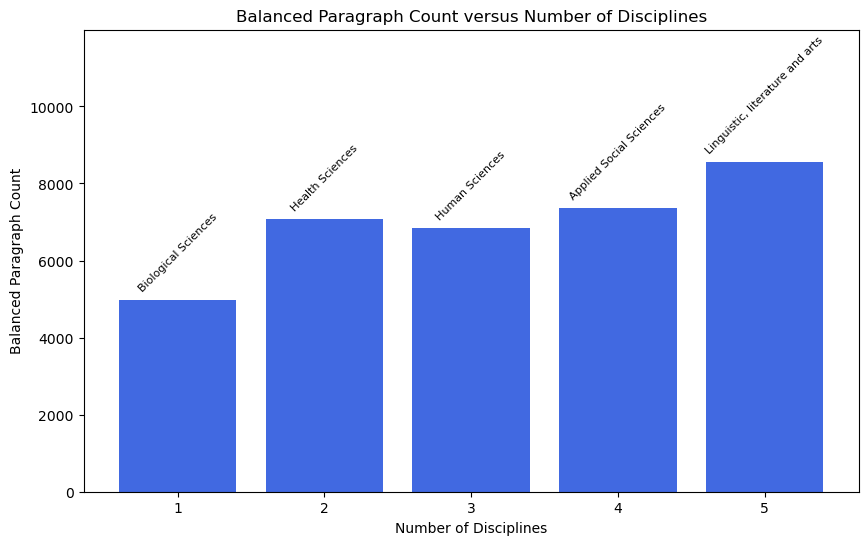

In [21]:
import matplotlib.pyplot as plt

# X-axis: Index + 1
x_axis = df_balancing.index + 1

# Y-axis: Balanced Paragraph Counts
y_axis = df_balancing['Balanced Paragraph Count']

# Disciplines for labels
labels = df_balancing['Discipline']

# Plotting the bar plot
plt.figure(figsize=(10, 6))
plt.bar(x_axis, y_axis, color='royalblue')

# Adjust the y-axis range
plt.ylim(0, y_axis.max() * 1.4)  # Extend y-axis to 40% above the maximum value

# Adding labels and title
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(x_axis)  # Ensure all indices are shown

# Adding the labels for each bar
for i, label in enumerate(labels):
    plt.text(x=x_axis[i], y=y_axis[i] + (y_axis.max() * 0.02), s=label, ha='center', va='bottom', fontsize=8, rotation=45)

# Saving as an image
plt.savefig(f"{output_directory}/{plot_filename}", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

#### Create a LaTeX table

In [22]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [23]:
tex_table = df_balancing.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [24]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

The same design of EL2AP was adopted in QJPP. Initially, QJPP was formatted with the same disciplines and the same proportion of number of texts per discipline as EL2AP.

### Balance the `Section` stratum

#### Inspect the sections by discipline

In [25]:
# List of disciplines
discipline = [
    'Health Sciences',
    'Biological Sciences',
    'Human Sciences',
    'Applied Social Sciences',
    'Linguistic, literature and arts'
]

# Create an empty dictionary to store unique sections for each discipline
unique_sections_by_discipline = {}

# Iterate through the disciplines
for d in discipline:
    # Slice the DataFrame based on the current discipline
    discipline_slice = df_qjpp[df_qjpp['Discipline'] == d]
    
    # Get unique sections, sorted in decreasing order
    unique_sections = sorted(discipline_slice['Section'].dropna().unique())
    
    # Store the result in the dictionary
    unique_sections_by_discipline[d] = unique_sections

# Display unique sections for each discipline
unique_sections_by_discipline

{'Health Sciences': ['Abstract',
  'Acknowledgements',
  'Conclusion',
  'Discussion',
  'Discussion, Conclusion',
  'Introduction',
  'Introduction, Literature Review',
  'Introduction, Literature Review, Methodology, Results, Discussion',
  'Introduction, Literature Review, Results, Discussion, Conclusion',
  'Literature Review',
  'Literature Review, Methodology, Results',
  'Literature Review, Methodology, Results, Discussion',
  'Methodology',
  'Results',
  'Results, Discussion'],
 'Biological Sciences': ['Abstract',
  'Acknowledgements',
  'Conclusion',
  'Discussion',
  'Discussion, Conclusion',
  'Introduction',
  'Introduction, Literature Review',
  'Introduction, Literature Review, Methodology, Results, Discussion',
  'Literature Review, Methodology, Results, Discussion',
  'Methodology',
  'Results',
  'Results, Discussion',
  'Results, Discussion, Conclusion'],
 'Human Sciences': ['Abstract',
  'Acknowledgements',
  'Conclusion',
  'Discussion',
  'Discussion, Conclusion',

To maintain the same design of EL2AP, the divergent patterns in the `non_standard_articles` list were removed.

The divergent patterns consist of unusually organised articles:
- `Introduction, Literature Review, Methodology, Results`: Texts that do not present a clear `Introduction` and conclude with a `Conclusion`;
- `Introduction, Literature Review, Methodology, Results, Discussion, Conclusion`: Texts that consist of a single piece of text;
- `Literature Review, Methodology, Results, Discussion, Conclusion`: Texts presenting a clear `Introduction` followed by a continuous text.

#### Inspect the non-standard texts by discipline

In [26]:
# Define the list of non-standard texts
non_standard_texts = [
    'Introduction, Literature Review, Methodology, Results',
    'Introduction, Literature Review, Methodology, Results, Discussion, Conclusion',
    'Literature Review, Methodology, Results, Discussion, Conclusion'
]

# Initialise an empty dictionary to store results by discipline
non_standard_by_discipline = {}

# Iterate through each unique discipline
for discipline in df_qjpp['Discipline'].unique():
    # Filter rows for the current discipline
    discipline_slice = df_qjpp[df_qjpp['Discipline'] == discipline]
    
    # Initialise a sub-dictionary for the current discipline
    non_standard_by_discipline[discipline] = {}
    
    # Iterate through the non-standard articles list
    for section in non_standard_texts:
        # Slice the DataFrame for the current section
        section_slice = discipline_slice[discipline_slice['Section'] == section]
        
        # Get unique Text IDs, sorted in increasing order
        unique_text_ids = sorted(section_slice['Text ID'].dropna().unique())
        
        # Add the result to the sub-dictionary
        non_standard_by_discipline[discipline][section] = unique_text_ids

# Display the results
non_standard_by_discipline

{'Health Sciences': {'Introduction, Literature Review, Methodology, Results': [],
  'Introduction, Literature Review, Methodology, Results, Discussion, Conclusion': [],
  'Literature Review, Methodology, Results, Discussion, Conclusion': []},
 'Biological Sciences': {'Introduction, Literature Review, Methodology, Results': [],
  'Introduction, Literature Review, Methodology, Results, Discussion, Conclusion': [],
  'Literature Review, Methodology, Results, Discussion, Conclusion': []},
 'Human Sciences': {'Introduction, Literature Review, Methodology, Results': [],
  'Introduction, Literature Review, Methodology, Results, Discussion, Conclusion': ['t000178'],
  'Literature Review, Methodology, Results, Discussion, Conclusion': ['t000190',
   't000192',
   't000193',
   't000194',
   't000203',
   't000205']},
 'Applied Social Sciences': {'Introduction, Literature Review, Methodology, Results': [],
  'Introduction, Literature Review, Methodology, Results, Discussion, Conclusion': [],
  '

The texts with divergent patterns are more frequently found in the `Health Sciences` discipline. Even so, they are not so frequent compared to the whole corpus. Therefore, it is safe to exclude them.

#### Exclude the non-standard texts

In [27]:
# Initialise an empty set to store unique Text IDs
consolidated_text_ids = set()

# Iterate through the dictionary
for discipline, sections in non_standard_by_discipline.items():
    for section, text_ids in sections.items():
        # Add the Text IDs from the current section to the set
        consolidated_text_ids.update(text_ids)

# Convert the set to a sorted list in decreasing order
sorted_consolidated_text_ids = sorted(consolidated_text_ids)

# Display the result
sorted_consolidated_text_ids

['t000178', 't000190', 't000192', 't000193', 't000194', 't000203', 't000205']

In [28]:
# Drop rows where 'Text ID' is in the 'sorted_consolidated_text_ids' list
df_qjpp = df_qjpp[~df_qjpp['Text ID'].isin(sorted_consolidated_text_ids)]

# Display the filtered DataFrame
df_qjpp

,Journal,Title,Authors,Published,Vol/Issue,URL,DOI,PDF URL,Discipline,ID,Text ID,Section,Paragraph,Text Paragraph
0,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,Abstract,Paragraph 1,The severe acute respiratory syndrome coronavi...
1,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,"Introduction, Literature Review",Paragraph 1,"Since its emergence in Wuhan, China, at the en..."
2,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,"Introduction, Literature Review",Paragraph 2,"By January 2022, approximately 49% of the glob..."
3,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,"Introduction, Literature Review",Paragraph 3,Low-income and lower-middle-income countries h...
4,Nature Medicine,Retrospectively modeling the effects of increa...,"Sam Moore, Edward M. Hill, Matt J. Keeling",2022-10-27,Not defined,https://www.nature.com/articles/s41591-022-020...,Not defined,https://www.nature.com/articles/s41591-022-020...,Health Sciences,natm000005,t000000,"Introduction, Literature Review",Paragraph 4,In high-income countries that have achieved hi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14334,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 32,"However, compared with the writers of New Zeal..."
14335,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 33,Prommas’s (2020 ) finding of the lower use of ...
14336,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 34,The findings of this mixed-methods study were ...
14337,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,Conclusion,Paragraph 1,"In this paper, we attempted to highlight the s..."


#### Reassess the balance

In [29]:
# Group by 'Discipline' and calculate the required metrics
df_balancing = df_qjpp.groupby('Discipline').agg(
    Text_Counts=('Text ID', lambda x: x.nunique()),  # Count unique Text IDs
    Paragraph_Counts=('Text ID', 'size')  # Count number of paragraphs (rows)
).reset_index()

# Rename the columns
df_balancing.rename(columns={
    'Text_Counts': 'Text Count',
    'Paragraph_Counts': 'Paragraph Count'
}, inplace=True)

# Sort the DataFrame by 'Paragraph Counts' in descending order
df_balancing = df_balancing.sort_values(by='Paragraph Count', ascending=False).reset_index(drop=True)

# Add 'Average Paragraph Count per Text'
df_balancing['Average Paragraph Count per Text'] = df_balancing['Paragraph Count'] / df_balancing['Text Count']

# Add 'Balanced Paragraph Counts' using direct computation with the index
df_balancing['Balanced Paragraph Count'] = df_balancing['Paragraph Count'] * (df_balancing.index + 1)

# Display the DataFrame
df_balancing

,Discipline,Text Count,Paragraph Count,Average Paragraph Count per Text,Balanced Paragraph Count
0,Biological Sciences,90,4974,55.266667,4974
1,Health Sciences,88,3534,40.159091,7068
2,Human Sciences,44,1980,45.000000,5940
3,Applied Social Sciences,42,1840,43.809524,7360
4,"Linguistic, literature and arts",29,1713,59.068966,8565


In [30]:
x_label = 'Discipline'
y_label = 'Paragraph Count'
title = 'Paragraph Count per Discipline 1'
filename = 'df_qjpp_paragraph_count_per_discipline1'
plot_filename = f"{filename}.png"

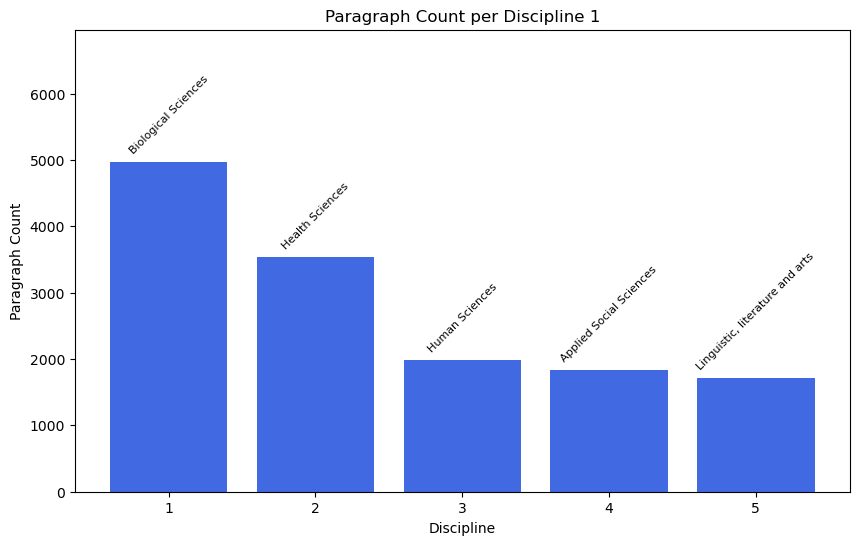

In [31]:
import matplotlib.pyplot as plt

# X-axis: Index + 1
x_axis = df_balancing.index + 1

# Y-axis: Balanced Paragraph Counts
y_axis = df_balancing['Paragraph Count']

# Disciplines for labels
labels = df_balancing['Discipline']

# Plotting the bar plot
plt.figure(figsize=(10, 6))
plt.bar(x_axis, y_axis, color='royalblue')

# Adjust the y-axis range
plt.ylim(0, y_axis.max() * 1.4)  # Extend y-axis to 40% above the maximum value

# Adding labels and title
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(x_axis)  # Ensure all indices are shown

# Adding the labels for each bar
for i, label in enumerate(labels):
    plt.text(x=x_axis[i], y=y_axis[i] + (y_axis.max() * 0.02), s=label, ha='center', va='bottom', fontsize=8, rotation=45)

# Saving as an image
plt.savefig(f"{output_directory}/{plot_filename}", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

#### Create a LaTeX table

In [32]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [33]:
tex_table = df_balancing.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [34]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

`Biological Sciences` and `Health Sciences` stand out. Therefore, the number of texts in both should be reduced. Since `Biological Sciences` has an average paragraph count per text similar to `Linguistic, literature and arts`, the proposed solution is reducing the number of `Biological Sciences` texts to 35. Since `Health Sciences` has an average paragraph count per text similar to `Applied Social Sciences`, the proposed solution is reducing the number of `Health Sciences` texts to 45.

#### Inspect the number of paragraphs per section per discipline

In [35]:
# Group by 'Discipline' and 'Section' to count the number of paragraphs
df_section_paragraph = df_qjpp.groupby(['Discipline', 'Section']).size().reset_index(name='Paragraph Count')

# Display the resulting DataFrame
df_section_paragraph

,Discipline,Section,Paragraph Count
0,Applied Social Sciences,Abstract,67
1,Applied Social Sciences,Acknowledgements,23
2,Applied Social Sciences,Conclusion,98
3,Applied Social Sciences,Discussion,194
4,Applied Social Sciences,"Discussion, Conclusion",61
...,...,...,...
63,"Linguistic, literature and arts","Literature Review, Methodology, Results, Discu...",192
64,"Linguistic, literature and arts",Methodology,226
65,"Linguistic, literature and arts","Methodology, Results, Discussion",147
66,"Linguistic, literature and arts",Results,268


In [36]:
df_section_paragraph.to_excel(f"{output_directory}/df_section_paragraph.xlsx")

#### Inspect the top `Biological Sciences` texts in terms of number of paragraphs

In [37]:
# Filter rows where 'Discipline' is 'Biological Sciences'
biological_sciences_slice = df_qjpp[df_qjpp['Discipline'] == 'Biological Sciences']

# Group by 'Text ID' and count the number of paragraphs
df_top_biological_sciences = biological_sciences_slice.groupby('Text ID').size().reset_index(name='Paragraph Count')

# Sort by 'Paragraph Count' in descending order
df_top_biological_sciences = df_top_biological_sciences.sort_values(by='Paragraph Count', ascending=False).reset_index(drop=True)

# Display the resulting DataFrame
df_top_biological_sciences

,Text ID,Paragraph Count
0,t000119,157
1,t000105,117
2,t000112,108
3,t000129,106
4,t000109,99
...,...,...
85,t000175,21
86,t000176,21
87,t000159,18
88,t000136,18


##### Export to a file

In [38]:
df_top_biological_sciences.to_excel(f"{output_directory}/df_top_biological_sciences.xlsx")

#### Inspect the top `Health Sciences` texts in terms of number of paragraphs

In [39]:
# Filter rows where 'Discipline' is 'Health Sciences'
health_sciences_slice = df_qjpp[df_qjpp['Discipline'] == 'Health Sciences']

# Group by 'Text ID' and count the number of paragraphs
df_top_health_sciences = health_sciences_slice.groupby('Text ID').size().reset_index(name='Paragraph Count')

# Sort by 'Paragraph Count' in descending order
df_top_health_sciences = df_top_health_sciences.sort_values(by='Paragraph Count', ascending=False).reset_index(drop=True)

# Display the resulting DataFrame
df_top_health_sciences

,Text ID,Paragraph Count
0,t000013,116
1,t000035,70
2,t000020,68
3,t000018,68
4,t000017,65
...,...,...
83,t000062,27
84,t000069,25
85,t000051,25
86,t000019,18


##### Export to a file

In [40]:
df_top_health_sciences.to_excel(f"{output_directory}/df_top_health_sciences.xlsx")

#### Randomly select 35 `Biological Sciences` texts to be retained

In [41]:
# Ensure 'Text ID' column has enough unique items
if len(df_top_biological_sciences['Text ID'].unique()) >= 35:
    # Generate a random sample of 35 'Text ID's
    random_text_ids = random.sample(list(df_top_biological_sciences['Text ID'].unique()), 35)
else:
    print("Not enough unique 'Text ID' values to sample 35 items.")

# Display the random sample
random_text_ids

['t000128',
 't000098',
 't000150',
 't000159',
 't000176',
 't000123',
 't000156',
 't000113',
 't000157',
 't000117',
 't000168',
 't000129',
 't000108',
 't000099',
 't000130',
 't000169',
 't000097',
 't000122',
 't000144',
 't000095',
 't000126',
 't000148',
 't000160',
 't000100',
 't000136',
 't000107',
 't000149',
 't000151',
 't000133',
 't000112',
 't000127',
 't000171',
 't000146',
 't000103',
 't000102']

#### Build the list of exclusion of `Biological Sciences` texts

In [42]:
# Get all 'Text ID' values from the 'df_top_biological_sciences' DataFrame
all_text_ids = df_top_biological_sciences['Text ID'].unique()

# Identify 'Text ID' values to be excluded
excluded_text_ids = [text_id for text_id in all_text_ids if text_id not in random_text_ids]

# Display the list of 'Text ID's to be excluded
#excluded_text_ids

#### Exclude the `Biological Sciences` texts

In [43]:
# Exclude rows where 'Text ID' is in the 'excluded_text_ids' list
df_qjpp = df_qjpp[~df_qjpp['Text ID'].isin(excluded_text_ids)]

# Display the resulting DataFrame
#df_qjpp

#### Reassess the balance

In [44]:
# Group by 'Discipline' and calculate the required metrics
df_balancing = df_qjpp.groupby('Discipline').agg(
    Text_Counts=('Text ID', lambda x: x.nunique()),  # Count unique Text IDs
    Paragraph_Counts=('Text ID', 'size')  # Count number of paragraphs (rows)
).reset_index()

# Rename the columns
df_balancing.rename(columns={
    'Text_Counts': 'Text Counts',
    'Paragraph_Counts': 'Paragraph Counts'
}, inplace=True)

# Sort the DataFrame by 'Paragraph Counts' in descending order
df_balancing = df_balancing.sort_values(by='Paragraph Counts', ascending=False).reset_index(drop=True)

# Add 'Average Paragraph Count per Text'
df_balancing['Average Paragraph Count per Text'] = df_balancing['Paragraph Counts'] / df_balancing['Text Counts']

# Add 'Balanced Paragraph Counts' using direct computation with the index
df_balancing['Balanced Paragraph Counts'] = df_balancing['Paragraph Counts'] * (df_balancing.index + 1)

# Display the DataFrame
df_balancing

,Discipline,Text Counts,Paragraph Counts,Average Paragraph Count per Text,Balanced Paragraph Counts
0,Health Sciences,88,3534,40.159091,3534
1,Biological Sciences,35,2077,59.342857,4154
2,Human Sciences,44,1980,45.000000,5940
3,Applied Social Sciences,42,1840,43.809524,7360
4,"Linguistic, literature and arts",29,1713,59.068966,8565


In [45]:
# Group by 'Discipline' and 'Section' to count the number of paragraphs
df_section_paragraph = df_qjpp.groupby(['Discipline', 'Section']).size().reset_index(name='Paragraph Count')

# Display the resulting DataFrame
df_section_paragraph

,Discipline,Section,Paragraph Count
0,Applied Social Sciences,Abstract,67
1,Applied Social Sciences,Acknowledgements,23
2,Applied Social Sciences,Conclusion,98
3,Applied Social Sciences,Discussion,194
4,Applied Social Sciences,"Discussion, Conclusion",61
...,...,...,...
61,"Linguistic, literature and arts","Literature Review, Methodology, Results, Discu...",192
62,"Linguistic, literature and arts",Methodology,226
63,"Linguistic, literature and arts","Methodology, Results, Discussion",147
64,"Linguistic, literature and arts",Results,268


In [46]:
# Filter rows where 'Discipline' is 'Biological Sciences'
biological_sciences_slice = df_qjpp[df_qjpp['Discipline'] == 'Biological Sciences']

# Group by 'Text ID' and count the number of paragraphs
df_top_biological_sciences = biological_sciences_slice.groupby('Text ID').size().reset_index(name='Paragraph Count')

# Sort by 'Paragraph Count' in descending order
df_top_biological_sciences = df_top_biological_sciences.sort_values(by='Paragraph Count', ascending=False).reset_index(drop=True)

# Display the resulting DataFrame
df_top_biological_sciences

,Text ID,Paragraph Count
0,t000112,108
1,t000129,106
2,t000117,93
3,t000171,87
4,t000148,86
5,t000149,81
6,t000122,80
7,t000128,78
8,t000133,78
9,t000099,77


##### Export to a file

In [47]:
df_section_paragraph.to_excel(f"{output_directory}/df_section_paragraph2.xlsx")

#### Randomly select 45 `Health Sciences` texts to be retained

In [48]:
# Ensure 'Text ID' column has enough unique items
if len(df_top_health_sciences['Text ID'].unique()) >= 45:
    # Generate a random sample of 45 'Text ID's
    random_text_ids = random.sample(list(df_top_health_sciences['Text ID'].unique()), 45)
else:
    print("Not enough unique 'Text ID' values to sample 45 items.")

# Display the random sample
random_text_ids

['t000009',
 't000014',
 't000049',
 't000030',
 't000013',
 't000085',
 't000033',
 't000084',
 't000058',
 't000020',
 't000018',
 't000017',
 't000051',
 't000028',
 't000059',
 't000066',
 't000038',
 't000056',
 't000083',
 't000040',
 't000026',
 't000072',
 't000023',
 't000052',
 't000010',
 't000055',
 't000035',
 't000007',
 't000069',
 't000016',
 't000087',
 't000053',
 't000047',
 't000068',
 't000003',
 't000002',
 't000062',
 't000008',
 't000029',
 't000011',
 't000001',
 't000063',
 't000080',
 't000032',
 't000046']

#### Build the list of exclusion of `Health Sciences` texts

In [49]:
# Get all 'Text ID' values from the 'df_top_health_sciences' DataFrame
all_text_ids = df_top_health_sciences['Text ID'].unique()

# Identify 'Text ID' values to be excluded
excluded_text_ids = [text_id for text_id in all_text_ids if text_id not in random_text_ids]

# Display the list of 'Text ID's to be excluded
#excluded_text_ids

#### Exclude the `Health Sciences` texts

In [50]:
# Exclude rows where 'Text ID' is in the 'excluded_text_ids' list
df_qjpp = df_qjpp[~df_qjpp['Text ID'].isin(excluded_text_ids)]

# Display the resulting DataFrame
#df_qjpp

#### Reassess the balance

In [51]:
# Group by 'Discipline' and calculate the required metrics
df_balancing = df_qjpp.groupby('Discipline').agg(
    Text_Counts=('Text ID', lambda x: x.nunique()),  # Count unique Text IDs
    Paragraph_Counts=('Text ID', 'size')  # Count number of paragraphs (rows)
).reset_index()

# Rename the columns
df_balancing.rename(columns={
    'Text_Counts': 'Text Counts',
    'Paragraph_Counts': 'Paragraph Counts'
}, inplace=True)

# Sort the DataFrame by 'Paragraph Counts' in descending order
df_balancing = df_balancing.sort_values(by='Paragraph Counts', ascending=False).reset_index(drop=True)

# Add 'Average Paragraph Count per Text'
df_balancing['Average Paragraph Count per Text'] = df_balancing['Paragraph Counts'] / df_balancing['Text Counts']

# Add 'Balanced Paragraph Counts' using direct computation with the index
df_balancing['Balanced Paragraph Counts'] = df_balancing['Paragraph Counts'] * (df_balancing.index + 1)

# Display the DataFrame
df_balancing

,Discipline,Text Counts,Paragraph Counts,Average Paragraph Count per Text,Balanced Paragraph Counts
0,Biological Sciences,35,2077,59.342857,2077
1,Human Sciences,44,1980,45.000000,3960
2,Health Sciences,45,1889,41.977778,5667
3,Applied Social Sciences,42,1840,43.809524,7360
4,"Linguistic, literature and arts",29,1713,59.068966,8565


In [52]:
# Group by 'Discipline' and 'Section' to count the number of paragraphs
df_section_paragraph = df_qjpp.groupby(['Discipline', 'Section']).size().reset_index(name='Paragraph Count')

# Display the resulting DataFrame
df_section_paragraph

,Discipline,Section,Paragraph Count
0,Applied Social Sciences,Abstract,67
1,Applied Social Sciences,Acknowledgements,23
2,Applied Social Sciences,Conclusion,98
3,Applied Social Sciences,Discussion,194
4,Applied Social Sciences,"Discussion, Conclusion",61
...,...,...,...
59,"Linguistic, literature and arts","Literature Review, Methodology, Results, Discu...",192
60,"Linguistic, literature and arts",Methodology,226
61,"Linguistic, literature and arts","Methodology, Results, Discussion",147
62,"Linguistic, literature and arts",Results,268


In [53]:
# Filter rows where 'Discipline' is 'Health Sciences'
health_sciences_slice = df_qjpp[df_qjpp['Discipline'] == 'Health Sciences']

# Group by 'Text ID' and count the number of paragraphs
df_top_health_sciences = health_sciences_slice.groupby('Text ID').size().reset_index(name='Paragraph Count')

# Sort by 'Paragraph Count' in descending order
df_top_health_sciences = df_top_health_sciences.sort_values(by='Paragraph Count', ascending=False).reset_index(drop=True)

# Display the resulting DataFrame
df_top_health_sciences

,Text ID,Paragraph Count
0,t000013,116
1,t000035,70
2,t000018,68
3,t000020,68
4,t000017,65
5,t000008,59
6,t000033,57
7,t000032,54
8,t000001,53
9,t000052,52


##### Export to a file

In [54]:
df_section_paragraph.to_excel(f"{output_directory}/df_section_paragraph3.xlsx")

## Finalised `QJPP` corpus

**Important**: Due to the random component that was introduced, the corpus changes every time this notebook is reprocessed.

In [55]:
df_qjpp

,Journal,Title,Authors,Published,Vol/Issue,URL,DOI,PDF URL,Discipline,ID,Text ID,Section,Paragraph,Text Paragraph
44,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,Abstract,Paragraph 1,High systolic blood pressure (SBP) is a major ...
45,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 1,High SBP is a common modifiable risk factor fo...
46,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 2,The association between SBP and IHD is one of ...
47,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 3,Despite the extensive body of evidence indicat...
48,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 4,Investigation of SBP as a continuous risk func...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14334,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 32,"However, compared with the writers of New Zeal..."
14335,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 33,Prommas’s (2020 ) finding of the lower use of ...
14336,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 34,The findings of this mixed-methods study were ...
14337,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,Conclusion,Paragraph 1,"In this paper, we attempted to highlight the s..."


### Create the column `Section Code`

In [56]:
# Create a list of sections sorted in increasing order
section_list = sorted(df_qjpp['Section'].dropna().unique())

# Create the dictionary with scheme 's1', 's2', etc.
section_dict = {f"s{i+1}": section for i, section in enumerate(section_list)}

# Display the dictionary
section_dict

{'s1': 'Abstract',
 's2': 'Acknowledgements',
 's3': 'Conclusion',
 's4': 'Discussion',
 's5': 'Discussion, Conclusion',
 's6': 'Introduction',
 's7': 'Introduction, Literature Review',
 's8': 'Introduction, Literature Review, Methodology, Results, Discussion',
 's9': 'Introduction, Literature Review, Results, Discussion, Conclusion',
 's10': 'Literature Review',
 's11': 'Literature Review, Methodology',
 's12': 'Literature Review, Methodology, Results',
 's13': 'Literature Review, Methodology, Results, Discussion',
 's14': 'Methodology',
 's15': 'Methodology, Results',
 's16': 'Methodology, Results, Discussion',
 's17': 'Results',
 's18': 'Results, Discussion'}

#### `EL2AP` section dictionary

In [57]:
el2ap_section_dict = {
    's1': 'Abstract',
    's2': 'Acknowledgements',
    's3': 'Comments to the Editor',
    's4': 'Conclusion',
    's5': 'Discussion',
    's6': 'Discussion, Conclusion',
    's7': 'Introduction',
    's8': 'Introduction, Literature Review',
    's9': 'Introduction, Literature Review, Methodology',
    's10': 'Introduction, Literature Review, Methodology, Results, Discussion',
    's11': 'Literature Review',
    's12': 'Literature Review, Methodology, Results',
    's13': 'Literature Review, Methodology, Results, Discussion',
    's14': 'Methodology',
    's15': 'Methodology, Results',
    's16': 'Methodology, Results, Discussion',
    's17': 'Methodology, Results, Discussion,',
    's18': 'Methodology, Results, Discussion, Conclusion',
    's19': 'Results',
    's20': 'Results, Discussion',
    's21': 'Results, Discussion, Conclusion'
}

#### `QJPP` section dictionary

In [58]:
qjpp_section_dict = {
    's1': 'Abstract',
    's2': 'Acknowledgements',
    's3': 'Conclusion',
    's4': 'Discussion',
    's5': 'Discussion, Conclusion',
    's6': 'Introduction',
    's7': 'Introduction, Literature Review',
    's8': 'Introduction, Literature Review, Methodology, Results, Discussion',
    's9': 'Introduction, Literature Review, Results, Discussion, Conclusion',
    's10': 'Literature Review',
    's11': 'Literature Review, Methodology',
    's12': 'Literature Review, Methodology, Results',
    's13': 'Literature Review, Methodology, Results, Discussion',
    's14': 'Methodology',
    's15': 'Methodology, Results',
    's16': 'Methodology, Results, Discussion',
    's17': 'Results',
    's18': 'Results, Discussion',
    's19': 'Results, Discussion, Conclusion'
}

#### `EL2AP + QJPP` section dictionary

In [59]:
el2ap_qjpp_section_dict = {
    's1': 'Abstract',
    's2': 'Acknowledgements',
    's3': 'Comments to the Editor',
    's4': 'Conclusion',
    's5': 'Discussion',
    's6': 'Discussion, Conclusion',
    's7': 'Introduction',
    's8': 'Introduction, Literature Review',
    's9': 'Introduction, Literature Review, Methodology',
    's10': 'Introduction, Literature Review, Methodology, Results, Discussion',
    's11': 'Literature Review',
    's12': 'Literature Review, Methodology, Results',
    's13': 'Literature Review, Methodology, Results, Discussion',
    's14': 'Methodology',
    's15': 'Methodology, Results',
    's16': 'Methodology, Results, Discussion',
    's17': 'Methodology, Results, Discussion,',
    's18': 'Methodology, Results, Discussion, Conclusion',
    's19': 'Results',
    's20': 'Results, Discussion',
    's21': 'Results, Discussion, Conclusion',
    's22': 'Introduction, Literature Review, Results, Discussion, Conclusion',
    's23': 'Literature Review, Methodology'
}

In [60]:
# Reverse the dictionary: swap keys and values
reversed_section_dict = {value: key for key, value in el2ap_qjpp_section_dict.items()}

# Create the 'Section Code' column based on the 'Section' column
df_qjpp['Section Code'] = df_qjpp['Section'].map(reversed_section_dict)

# Display the updated DataFrame
df_qjpp

,Journal,Title,Authors,Published,Vol/Issue,URL,DOI,PDF URL,Discipline,ID,Text ID,Section,Paragraph,Text Paragraph,Section Code
44,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,Abstract,Paragraph 1,High systolic blood pressure (SBP) is a major ...,s1
45,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 1,High SBP is a common modifiable risk factor fo...,s8
46,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 2,The association between SBP and IHD is one of ...,s8
47,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 3,Despite the extensive body of evidence indicat...,s8
48,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 4,Investigation of SBP as a continuous risk func...,s8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14334,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 32,"However, compared with the writers of New Zeal...",s13
14335,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 33,Prommas’s (2020 ) finding of the lower use of ...,s13
14336,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 34,The findings of this mixed-methods study were ...,s13
14337,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,Conclusion,Paragraph 1,"In this paper, we attempted to highlight the s...",s4


### Create the column `Paragraph Code`

In [61]:
# Create the 'Paragraph Code' column by extracting the numeric part and prepending 'p'
df_qjpp['Paragraph Code'] = df_qjpp['Paragraph'].apply(lambda x: f"p{''.join(filter(str.isdigit, str(x)))}")

# Display the updated DataFrame
df_qjpp

,Journal,Title,Authors,Published,Vol/Issue,URL,DOI,PDF URL,Discipline,ID,Text ID,Section,Paragraph,Text Paragraph,Section Code,Paragraph Code
44,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,Abstract,Paragraph 1,High systolic blood pressure (SBP) is a major ...,s1,p1
45,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 1,High SBP is a common modifiable risk factor fo...,s8,p1
46,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 2,The association between SBP and IHD is one of ...,s8,p2
47,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 3,Despite the extensive body of evidence indicat...,s8,p3
48,Nature Medicine,Effects of elevated systolic blood pressure on...,"Christian Razo, Catherine A. Welgan, Gregory A...",2022-10-10,Not defined,https://www.nature.com/articles/s41591-022-019...,Not defined,https://www.nature.com/articles/s41591-022-019...,Health Sciences,natm000015,t000001,"Introduction, Literature Review",Paragraph 4,Investigation of SBP as a continuous risk func...,s8,p4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14334,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 32,"However, compared with the writers of New Zeal...",s13,p32
14335,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 33,Prommas’s (2020 ) finding of the lower use of ...,s13,p33
14336,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,"Literature Review, Methodology, Results, Discu...",Paragraph 34,The findings of this mixed-methods study were ...,s13,p34
14337,Corpora,Learner corpus research in New Zealand,"Anna Siyanova-Chanturia, Jean Parkinson, and T...",2022-09-27,"Volume 17, Issue Supplement",https://www.euppublishing.com/doi/full/10.3366...,https://doi.org/10.3366/cor.2022.0250,https://www.euppublishing.com/doi/pdf/10.3366/...,"Linguistic, literature and arts",corp000008,t000299,Conclusion,Paragraph 1,"In this paper, we attempted to highlight the s...",s4,p1


### Export to a file

In [62]:
df_qjpp.to_json(f"{output_directory}/df_qjpp_balanced.jsonl", orient='records', lines=True)

In [63]:
df_qjpp.to_excel(f"{output_directory}/df_qjpp_balanced.xlsx")

## Word Count

### Import the data into a DataFrame

In [64]:
df_qjpp_balanced = pd.read_json(f"{output_directory}/df_qjpp_balanced.jsonl", lines=True)

In [65]:
df_qjpp_balanced['Published'] = pd.to_datetime(df_qjpp_balanced['Published'], unit='ms')

### Calculate word counts for columns `Text Paragraph` and `Text Paragraph ChatGPT`

In [66]:
# Download the required NLTK data (only if you haven't already)
nltk.download('punkt')
nltk.download('punkt_tab')

# Create the new column 'Text Paragraph Word Count'
df_qjpp_balanced['Text Paragraph Word Count'] = df_qjpp_balanced['Text Paragraph'].apply(lambda x: len(word_tokenize(str(x))))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eyamr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\eyamr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### `QJPP` corpus number of texts

In [67]:
# Calculate the number of unique values in the 'Text ID' column
num_unique_text_ids = df_qjpp_balanced['Text ID'].nunique()

# Display the result
num_unique_text_ids

195

### `QJPP` corpus number of paragraphs

In [68]:
df_qjpp_balanced.shape[0]

9499

### `QJPP` corpus number of tokens

In [69]:
# Calculate the total number of words
total_word_count = df_qjpp_balanced['Text Paragraph Word Count'].sum()

# Display the total word count
total_word_count

1789557

In [70]:
# Create a DataFrame with corpus statistics
df_summary = pd.DataFrame({
    "Corpus": ["QJPP"],
    "Text Count": [df_qjpp_balanced['Text ID'].nunique()],
    "Paragraph Count": [df_qjpp_balanced.shape[0]],
    "Token Count": [df_qjpp_balanced['Text Paragraph Word Count'].sum()]
})

# Display the DataFrame
df_summary

,Corpus,Text Count,Paragraph Count,Token Count
0,QJPP,195,9499,1789557


### Create a LaTeX table

In [71]:
title = 'Reference Corpus Summary'
filename = 'df_qjpp_balanced_corpus_summary'

In [72]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [73]:
tex_table = df_summary.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [74]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

## Prepare data for tagging

### Import the data into a DataFrame

In [4]:
df_qjpp_balanced = pd.read_json(f"{output_directory}/df_qjpp_balanced.jsonl", lines=True)

In [5]:
df_qjpp_balanced['Published'] = pd.to_datetime(df_qjpp_balanced['Published'], unit='ms')

### Prepare `QJPP` data for tagging

- Export each paragraph in the column 'Text Paragraph' of the 'df_qjpp_balanced' DataFrame to individual text files;
- Introduce a '\n' every 10 words so that each file is organised in lines of 10 words;
- Organise the files into directories sequentially named 'qjpp/qjpp_1', 'qjpp/qjpp_2', etc., in the 'output_directory', with 1,000 files each.

In [77]:
# Counter for directories and files
dir_count = 1
file_count = 0

# Function to split text into lines of 10 words
def format_paragraph(text):
    words = text.split()  # Split the paragraph into words
    lines = [' '.join(words[i:i+10]) for i in range(0, len(words), 10)]  # Group words in chunks of 10
    return '\n'.join(lines)  # Join lines with a newline character

# Iterate through the DataFrame rows
for index, row in df_qjpp_balanced.iterrows():
    # Check if a new directory is needed
    if file_count % 1000 == 0:
        dir_name = f"{output_directory}/qjpp/qjpp_{dir_count}"
        os.makedirs(dir_name, exist_ok=True)  # Create the directory if it doesn't exist
        dir_count += 1

    # Generate the file name
    file_name = f"{dir_name}/{row['Text ID']}_{row['Section Code']}_{row['Paragraph Code']}_qjpp.txt"
    
    # Write the formatted paragraph to the file
    with open(file_name, 'w', encoding='utf-8', newline='\n') as file:
        formatted_paragraph = format_paragraph(str(row['Text Paragraph']))
        file.write(formatted_paragraph)
    
    # Increment the file counter
    file_count += 1

#### Alternative: group the files into a single folder

In [ ]:
# Function to split text into lines of 10 words
def format_paragraph(text):
    words = text.split()  # Split the paragraph into words
    lines = [' '.join(words[i:i+10]) for i in range(0, len(words), 10)]  # Group words in chunks of 10
    return '\n'.join(lines)  # Join lines with a newline character

# Iterate through the DataFrame rows
for index, row in df_qjpp_balanced.iterrows():
    dir_name = f"{output_directory}/qjpp_full"
    os.makedirs(dir_name, exist_ok=True)  # Create the directory if it doesn't exist

    # Generate the file name
    file_name = f"{dir_name}/{row['Text ID']}_{row['Section Code']}_{row['Paragraph Code']}_qjpp.txt"
    
    # Write the formatted paragraph to the file
    with open(file_name, 'w', encoding='utf-8', newline='\n') as file:
        formatted_paragraph = format_paragraph(str(row['Text Paragraph']))
        file.write(formatted_paragraph)